In [1]:
import time
from pathlib import Path
import pandas as pd
import scanpy as sc
import anndata as ad
from matplotlib import pyplot as plt
import re
import sys
import session_info

In [2]:
plt.rcParams['figure.figsize'] = (3,3)
#plt.rcParams['figure.dpi'] = 500

In [3]:
# Directories
base_dir = Path("/home/workspace/private/projects/kim/drg")
data_dir = base_dir / "data" / "scrna-seq"
input_dir = data_dir / "h5ad" / "03_scvi"

h5ad_out_dir = data_dir / "h5ad" / "04_clustered"
h5ad_out_dir.mkdir(parents=True, exist_ok=True)

In [4]:
input_adata = input_dir / "GSE254789.h5ad"
h5ad_out_1 = h5ad_out_dir / "GSE254789-scvi-leiden.h5ad"
h5ad_out_2 = h5ad_out_dir / "GSE254789-nonneurons.h5ad"

In [5]:
adata = sc.read_h5ad(input_dir / "GSE254789-scvi.h5ad")

In [6]:
adata.obs.predicted_doublets.value_counts()

predicted_doublets
False    57927
Name: count, dtype: int64

In [7]:
sc.pp.neighbors(adata, use_rep = 'X_scVI', random_state = 0) # Use latent representation to build neighbors graph
sc.tl.umap(adata, random_state = 0)

In [8]:
sc.tl.leiden(adata, key_added='leiden', resolution=0.5)

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


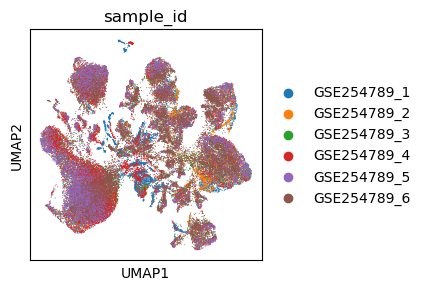

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


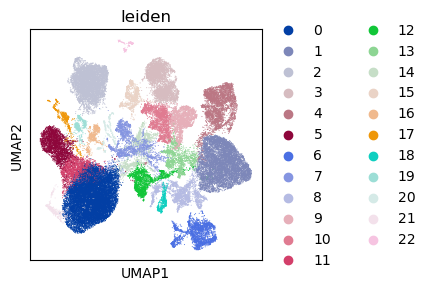

In [9]:
sc.pl.umap(adata, color = ['sample_id'], legend_fontsize = 10)
sc.pl.umap(adata, color = ['leiden'], legend_fontsize = 10)

# DE

In [10]:
#sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')
#df = sc.get.rank_genes_groups_df(adata, group = None)
#df = df.copy()
#df = df[(df.pvals_adj < 0.05) & (df.logfoldchanges > .5)].copy()
#df.head(5)

#sc.pl.rank_genes_groups(adata, groupby = 'leiden', method = 'wilcoxon')

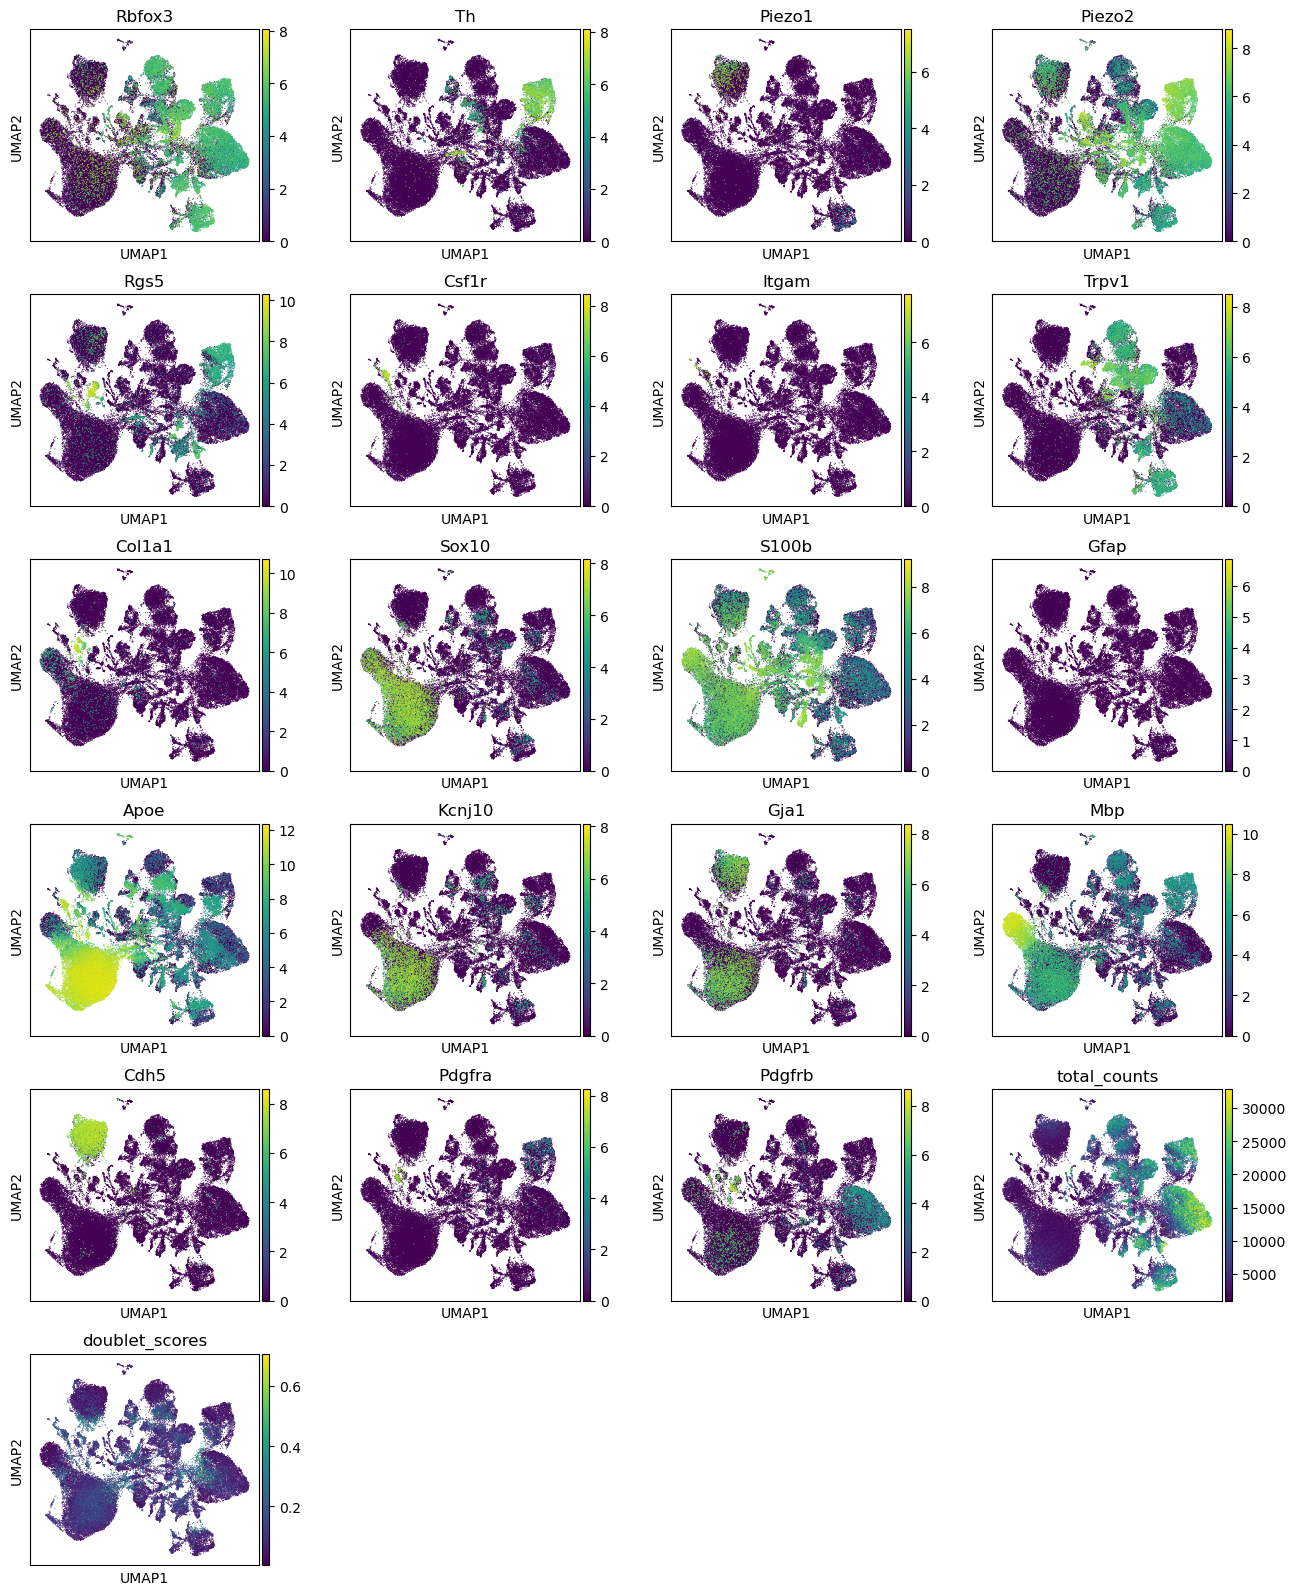

In [11]:
sc.pl.umap(adata, color = ['Rbfox3', 'Th', 'Piezo1', 'Piezo2', 'Rgs5', 'Csf1r', 'Itgam', 'Trpv1', 'Col1a1', 'Sox10', 'S100b', 'Gfap', 'Apoe', 'Kcnj10', 'Gja1', 'Mbp', 'Cdh5', 'Pdgfra', 'Pdgfrb', 'total_counts', 'doublet_scores'], legend_fontsize = 10)

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


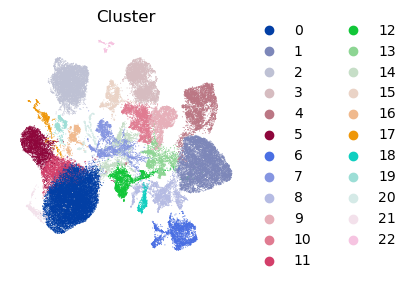

In [12]:
sc.pl.umap(adata, color = ['leiden'], title = "Cluster", frameon = False, size = 2)

In [13]:
# Number of cells
n_cells = adata.n_obs

# Median total counts per cell (transcript count)
median_total_counts = adata.obs['total_counts'].median()

# Median number of genes detected per cell
median_n_genes = adata.obs['n_genes_by_counts'].median()

# Print results
print(f"Number of cells: {n_cells:,}")
print(f"Median total counts per cell: {median_total_counts:.0f}")
print(f"Median number of detected genes per cell: {median_n_genes:.0f}")

Number of cells: 57,927
Median total counts per cell: 2879
Median number of detected genes per cell: 1574


# Clean messy clusters

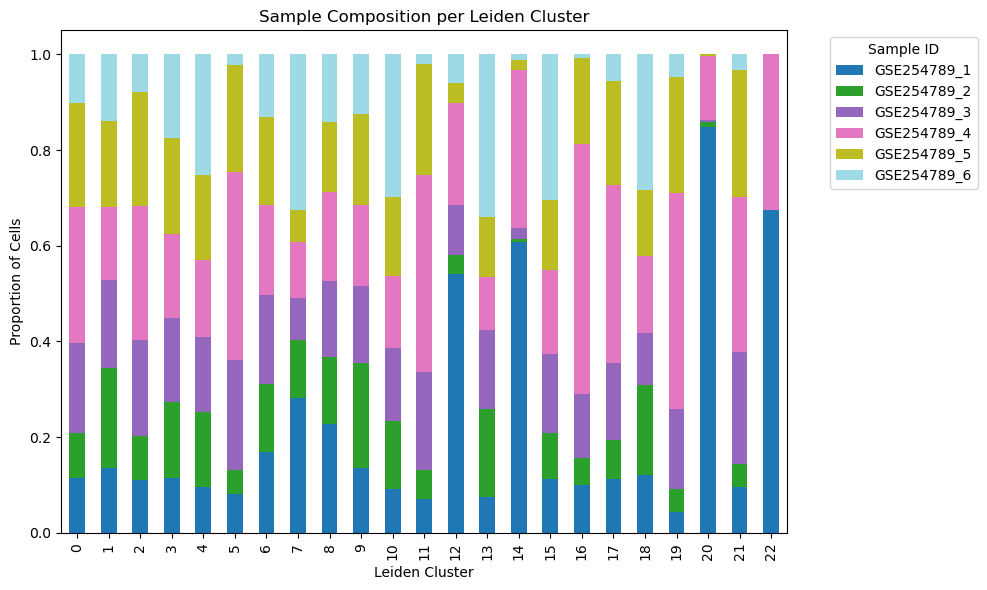

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Cross-tabulate leiden clusters by sample_id
cluster_sample_counts = pd.crosstab(adata.obs['leiden'], adata.obs['sample_id'])

# Normalize to get proportions per cluster
cluster_sample_props = cluster_sample_counts.div(cluster_sample_counts.sum(axis=1), axis=0)

# Plot
cluster_sample_props.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.ylabel('Proportion of Cells')
plt.xlabel('Leiden Cluster')
plt.title('Sample Composition per Leiden Cluster')
plt.legend(title='Sample ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [15]:
# Compute composition of each leiden cluster across samples
composition = (
    adata.obs
    .groupby(['leiden', 'sample_id'])
    .size()
    .unstack(fill_value=0)
)

# Normalize to get proportions per cluster
composition = composition.div(composition.sum(axis=1), axis=0)

/tmp/ipykernel_7803/3272796535.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['leiden', 'sample_id'])


/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


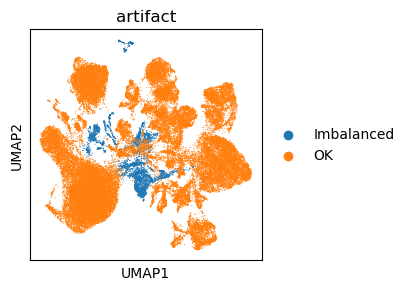

In [16]:
# Initialize the 'artifact' column with default value
adata.obs['artifact'] = 'OK'

# Find clusters where any sample exceeds threshold
threshold = 0.5
bad_clusters = composition[composition.max(axis=1) > threshold].index.tolist()

# Label those clusters as "Imbalanced"
adata.obs.loc[adata.obs['leiden'].isin(bad_clusters), 'artifact'] = 'Imbalanced'

sc.pl.umap(adata, color = 'artifact')

In [17]:
# keep pericytes
adata.obs.loc[adata.obs['leiden'] == '16', 'artifact'] = 'OK'

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Catego

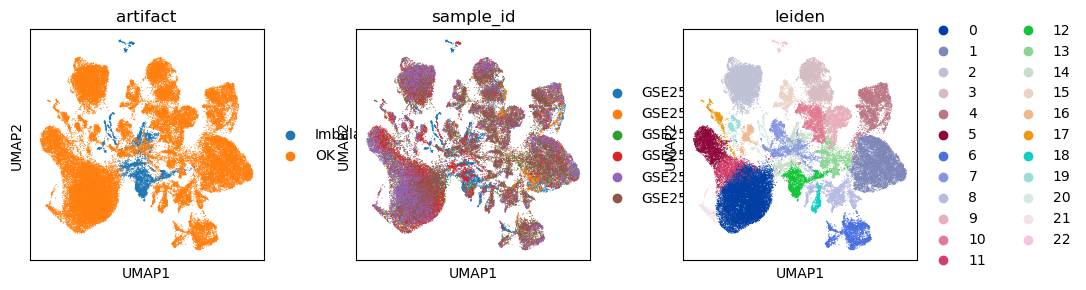

In [18]:
sc.pl.umap(adata, color = ['artifact', 'sample_id', 'leiden'])

# Divide non-neuronal cells

In [19]:
print(adata)
print('-' *40)
adata = adata[adata.obs['artifact'] == 'OK'].copy()
print(adata)

AnnData object with n_obs × n_vars = 57927 × 28694
    obs: 'GSE', 'GSM', 'sample_number', 'sample_id', 'experiment_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'doublet_scores', 'predicted_doublets', '_scvi_batch', '_scvi_labels', 'leiden', 'artifact'
    var: 'mt', 'ribosomal', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'neighbors', 'umap', 'leiden', 'sample_id_colors', 'leiden_colors', 'artifact_colors'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts', 'log1p', 'normalized_1e6'
    obsp: 'distances', 'connectivities'
----------------------------------------
AnnData object with n_obs × n_vars = 54155 × 28694
    obs: 'GSE', 'GSM', 'sample_number', 'sample_id', 'experiment_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'doublet_scores', 

/tmp/ipykernel_7803/801699793.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rbfox3_means = expr.groupby(cluster_labels).mean()
/tmp/ipykernel_7803/801699793.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rbfox3_z.index, y=rbfox3_z.values, palette="vlag")


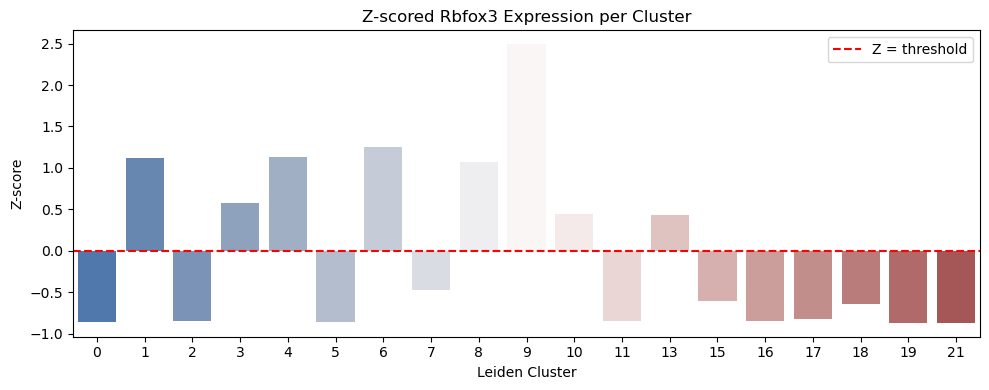

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Step 1: Compute average Rbfox3 expression per cluster
expr = adata.to_df()['Rbfox3']
cluster_labels = adata.obs['leiden']
rbfox3_means = expr.groupby(cluster_labels).mean()

# Step 2: Compute z-score
rbfox3_z = pd.Series(zscore(rbfox3_means), index=rbfox3_means.index)

# Step 3: Visualize
plt.figure(figsize=(10, 4))
sns.barplot(x=rbfox3_z.index, y=rbfox3_z.values, palette="vlag")
plt.axhline(0, color='red', linestyle='--', label='Z = threshold')
plt.title("Z-scored Rbfox3 Expression per Cluster")
plt.ylabel("Z-score")
plt.xlabel("Leiden Cluster")
plt.legend()
plt.tight_layout()
plt.show()


Low Rbfox3 clusters (excluding 18 and 7): ['0', '2', '5', '11', '16', '17', '19', '21']


/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


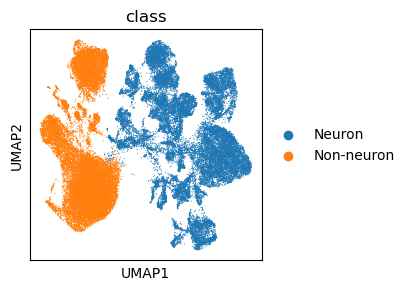

In [21]:

# Step 4: Label clusters based on Rbfox3 expression
adata.obs['class'] = 'Neuron'  # Default
low_clusters = rbfox3_z[rbfox3_z < 0].index.tolist()

# Keep clusters 18 and 7 as "Neuron"
excluded_clusters = ['18', '7', '15']
low_clusters = [cl for cl in low_clusters if cl not in excluded_clusters]
print("Low Rbfox3 clusters (excluding 18 and 7):", low_clusters)

adata.obs.loc[adata.obs['leiden'].isin(low_clusters), 'class'] = 'Non-neuron'

# Step 5: Visualize on UMAP
sc.pl.umap(adata, color='class')

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()


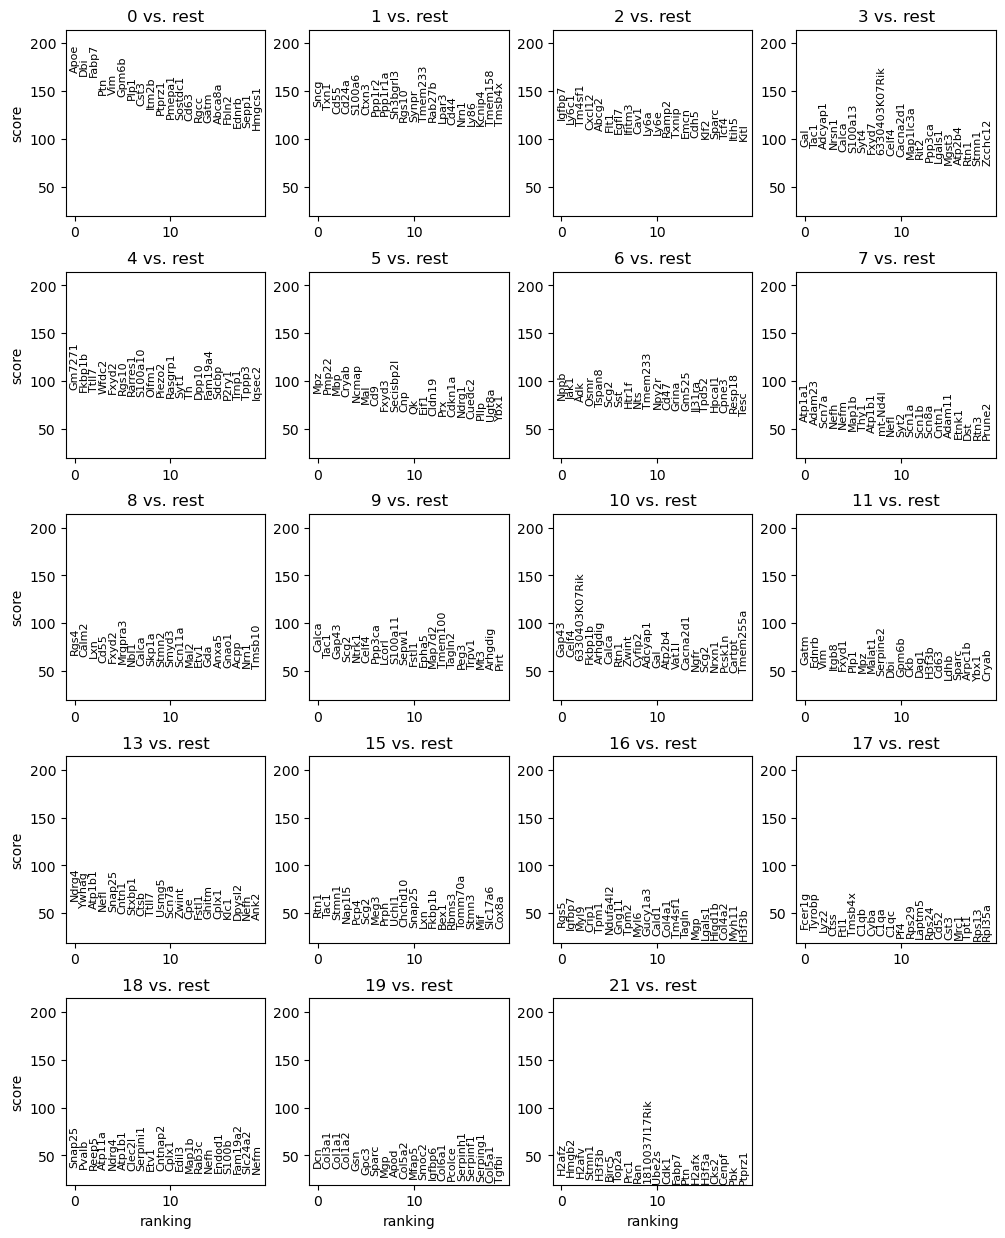

In [22]:
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')
df = sc.get.rank_genes_groups_df(adata, group = None)
df = df.copy()
df = df[(df.pvals_adj < 0.05) & (df.logfoldchanges > .5)].copy()
df.head(5)

sc.pl.rank_genes_groups(adata, groupby = 'leiden', method = 'wilcoxon')

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


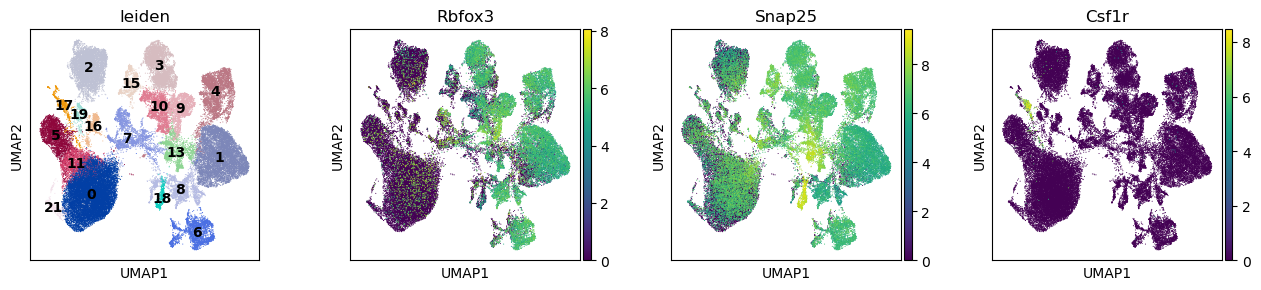

In [23]:
sc.pl.umap(adata, color = ['leiden', 'Rbfox3', 'Snap25', 'Csf1r'], legend_loc = 'on data')

In [24]:
bdata = adata[adata.obs['class'] == "Non-neuron"].copy()
bdata

AnnData object with n_obs × n_vars = 25512 × 28694
    obs: 'GSE', 'GSM', 'sample_number', 'sample_id', 'experiment_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'doublet_scores', 'predicted_doublets', '_scvi_batch', '_scvi_labels', 'leiden', 'artifact', 'class'
    var: 'mt', 'ribosomal', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'neighbors', 'umap', 'leiden', 'sample_id_colors', 'leiden_colors', 'artifact_colors', 'class_colors', 'rank_genes_groups'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts', 'log1p', 'normalized_1e6'
    obsp: 'distances', 'connectivities'

In [25]:
sc.pp.neighbors(bdata, use_rep = 'X_scVI', random_state = 0) # Use latent representation to build neighbors graph
sc.tl.umap(bdata, random_state = 0)

In [26]:
sc.tl.leiden(bdata, key_added='leiden', resolution=0.5)

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


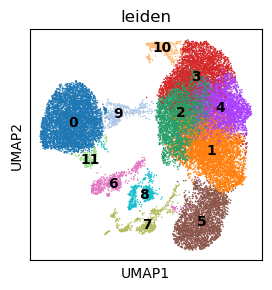

In [27]:
sc.pl.umap(bdata, color = ['leiden'], legend_loc = 'on data')


/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


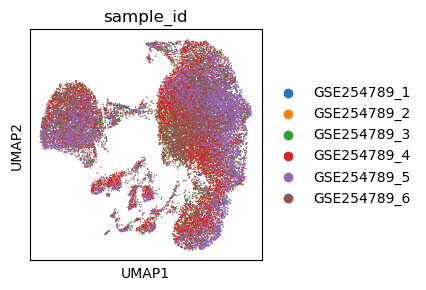

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


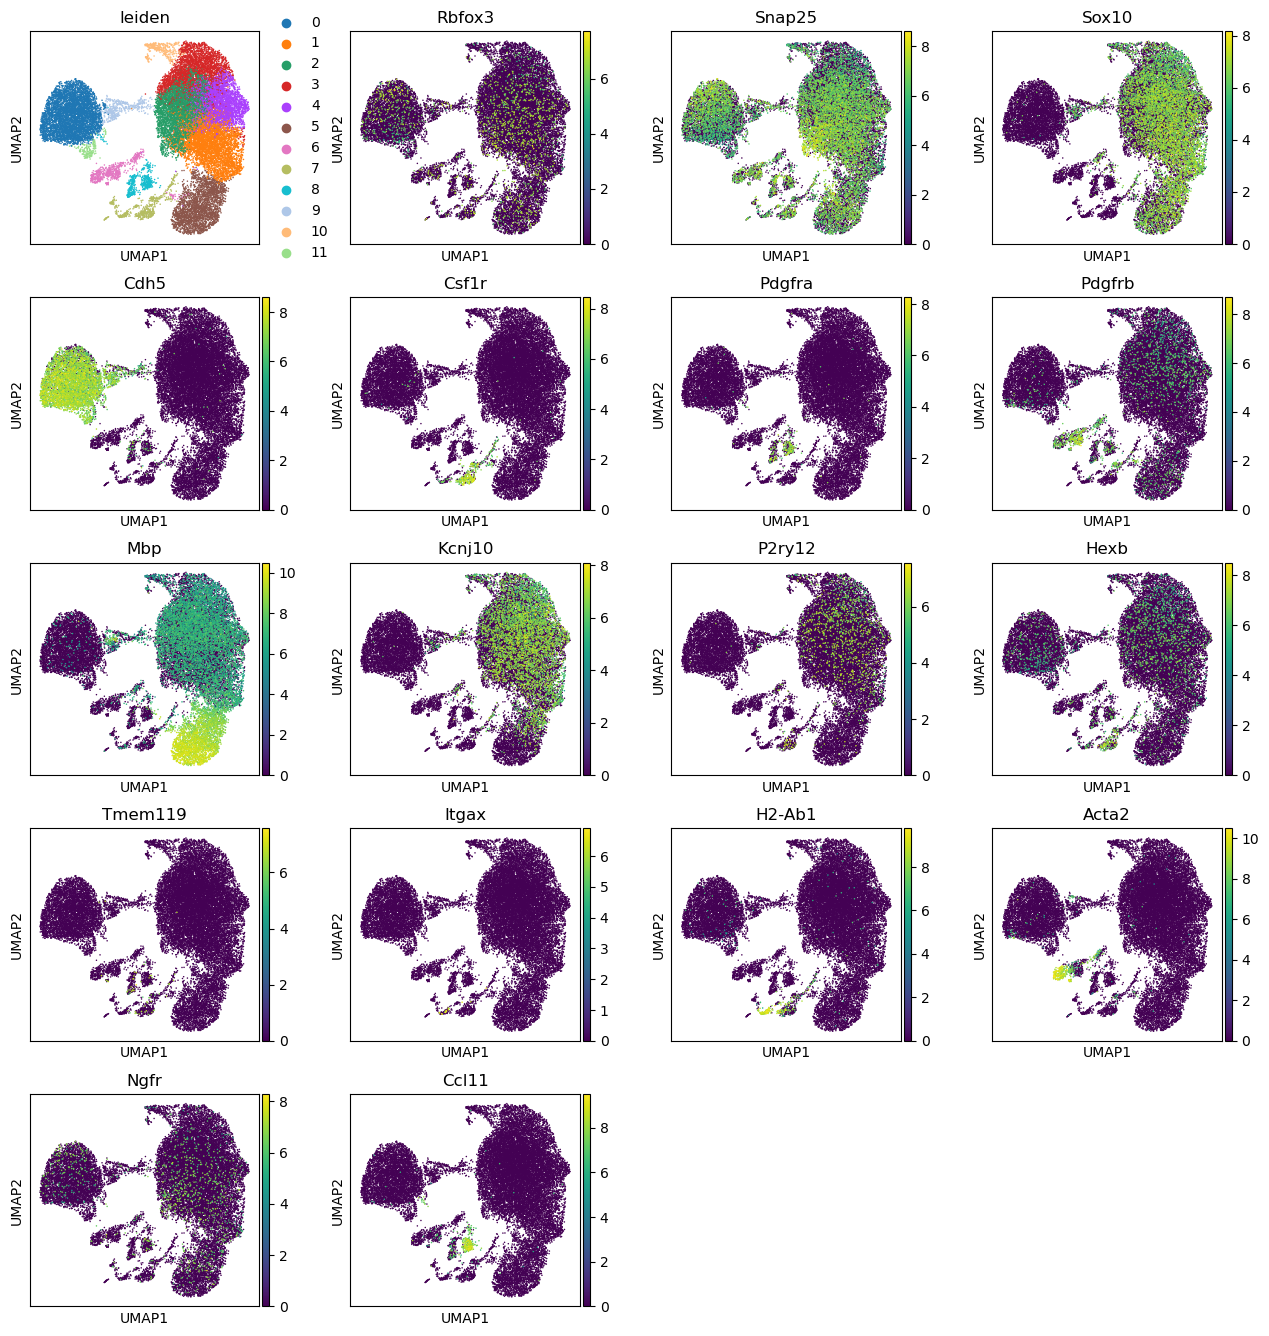

In [28]:
sc.pl.umap(bdata, color = ['sample_id'], legend_fontsize = 10)
sc.pl.umap(bdata, color = ['leiden', 'Rbfox3', 'Snap25', 'Sox10', 'Cdh5', 'Csf1r', 'Pdgfra', 'Pdgfrb', 'Mbp', 
                           'Kcnj10', 'P2ry12', 'Hexb', 'Tmem119', 'Itgax', 'H2-Ab1', 'Acta2', 'Ngfr', 'Ccl11'],
           legend_fontsize = 10)

In [29]:
def subcluster_leiden_clusters(bdata, cluster_res_dict):
    """
    Subcluster specific Leiden clusters in `bdata` using the scVI latent space,
    allowing for different resolutions per cluster.

    Parameters:
    - bdata: AnnData object with 'X_scVI' and 'leiden' in .obs
    - cluster_res_dict: dict where keys are cluster labels (str), values are resolutions (float)
    """
    import scanpy as sc
    import pandas as pd

    # Ensure leiden is categorical
    if not pd.api.types.is_categorical_dtype(bdata.obs['leiden']):
        bdata.obs['leiden'] = bdata.obs['leiden'].astype('category')
    current_cats = bdata.obs['leiden'].cat.categories.tolist()

    for cl, res in cluster_res_dict.items():
        sub = bdata[bdata.obs['leiden'] == cl].copy()
        if sub.n_obs < 5:
            print(f"Skipping cluster {cl} (too few cells)")
            continue

        sc.pp.neighbors(sub, use_rep='X_scVI')
        sc.tl.leiden(sub, resolution=res)
        sub.obs['leiden'] = sub.obs['leiden'].astype(str)
        sub.obs['leiden'] = [f"{cl}_{x}" for x in sub.obs['leiden']]

        # Add new categories
        new_cats = [x for x in sub.obs['leiden'].unique() if x not in current_cats]
        if new_cats:
            current_cats.extend(new_cats)
            bdata.obs['leiden'] = bdata.obs['leiden'].cat.set_categories(current_cats)

        # Update main object
        bdata.obs.loc[sub.obs_names, 'leiden'] = sub.obs['leiden']

    return bdata

In [30]:
# Use lower resolution for cluster 7 and higher for 8
res_dict = {'7': 0.05, '8': 0.05}
bdata = subcluster_leiden_clusters(bdata, res_dict)

/tmp/ipykernel_7803/4154822146.py:14: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(bdata.obs['leiden']):


/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


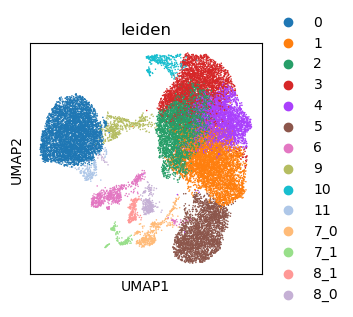

In [31]:
bdata.obs['leiden'] = bdata.obs['leiden'].astype('category')
bdata.obs['leiden'] = bdata.obs['leiden'].cat.remove_unused_categories()
sc.pl.umap(bdata, color='leiden')

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


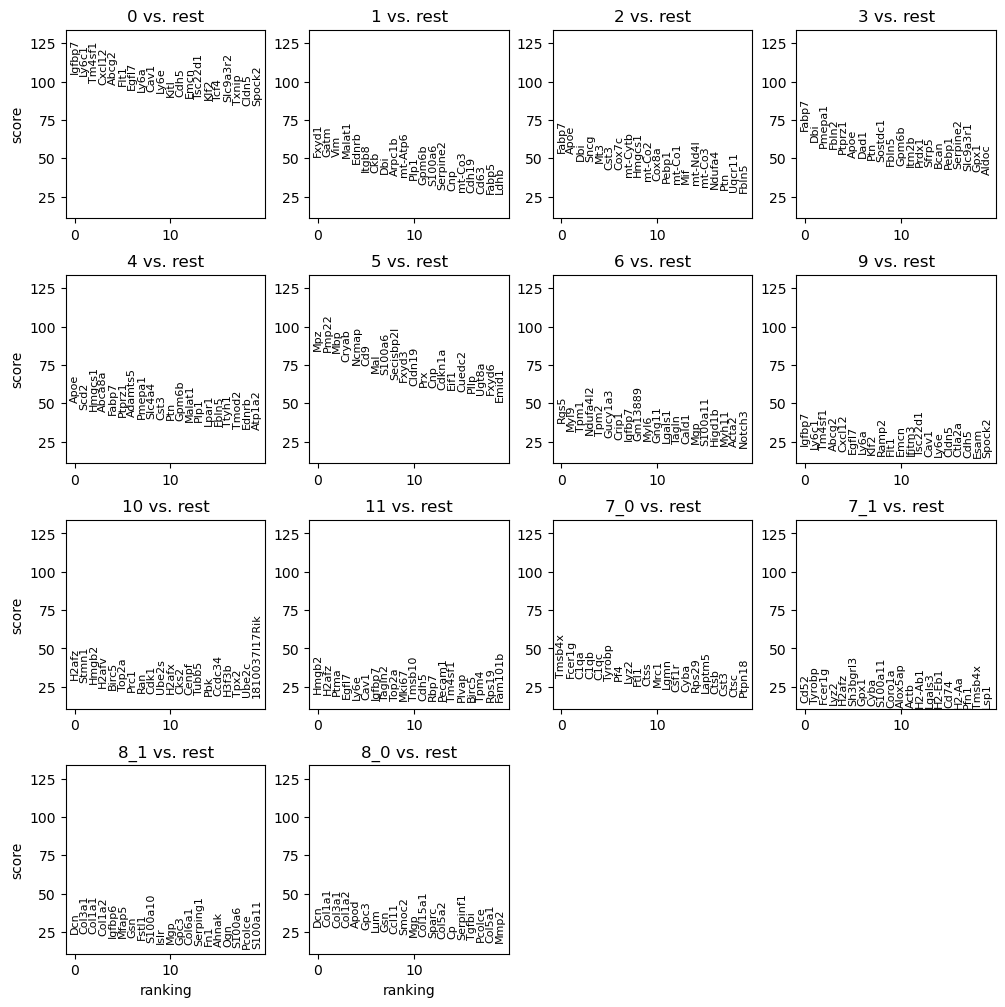

In [32]:
sc.tl.rank_genes_groups(bdata, groupby='leiden', method='wilcoxon')
sc.pl.rank_genes_groups(bdata, groupby = 'leiden', method = 'wilcoxon')

In [33]:
#{str(i): "" for i in range(14)}

In [34]:
cluster = {
    '0': 'Vascular_endothelial_1',
    '1': 'SGC',
    '2': 'SGC',
    '3': 'SGC',
    '4': 'SGC',
    '5': 'Schwann_cell',
    '6': 'Pericyte',
    '7_0': 'Macrophage_1',
    '7_1': 'Macrophage_2',
    '8_0': 'Fibroblast_1',
    '8_1': 'Fibroblast_2',
    '9': 'Vascular_endothelial_2',
    '10': 'Cycling SGC',
    '11': 'Angiogenic EC'
}

bdata.obs['cell_type'] = bdata.obs['leiden'].map(cluster).astype('category')

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


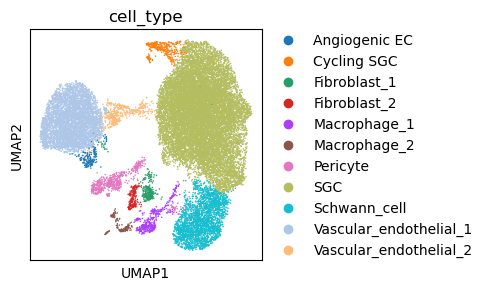

In [35]:
sc.pl.umap(bdata, color = 'cell_type')

## Export

In [36]:
adata.write_h5ad(h5ad_out_1, compression='gzip')

In [37]:
bdata.write_h5ad(h5ad_out_2, compression='gzip')